# Unseen Footage Evaluation

The one blocking item for the paper: every video the models were trained on is
also every video they have been evaluated on. Cross-validation gives an honest
estimate, but the pipeline has never faced input from outside the dataset.

This runs the deployed models on new footage and scores them against a
hand-marked timeline.

### Read section 2 before trusting any timing number

Detection is scored at plus or minus 8 frames, which is 67 ms. If the ground
truth itself is only accurate to 100 ms, a low F1 measures the annotation
rather than the model.

Section 2 tests the annotation for that, and everything downstream adapts to
what it finds. Shot count, class distribution and rally structure are robust to
imprecise timing; only per-shot matching is not.

**GPU required.** Runtime scales with clip length at roughly 5x realtime.


## 1 · Setup

In [4]:
BASE  = "/content/drive/MyDrive/tt_coach"
VIDEO = "test_match2"          # expects raw/external/{VIDEO}.mp4 and _gt.txt

from google.colab import drive
drive.mount('/content/drive')

import json, re, textwrap, collections
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import cv2
from sklearn.metrics import classification_report, confusion_matrix, f1_score

BASE = Path(BASE)
EXT  = BASE/"raw/external"
CLASSES = ["serve", "attack", "control", "defence"]
C2I = {c: i for i, c in enumerate(CLASSES)}

mpl.rcParams.update({"figure.dpi": 130, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25,
                     "figure.constrained_layout.use": True})
PAL = {"serve": "#1d4ed8", "attack": "#b91c1c",
       "control": "#065f46", "defence": "#854d0e"}

vid_path = EXT/f"{VIDEO}.mp4"
gt_path  = EXT/f"{VIDEO}_gt.txt"
assert vid_path.exists(), f"missing {vid_path}"
assert gt_path.exists(),  f"missing {gt_path}"

cap = cv2.VideoCapture(str(vid_path))
FPS = cap.get(cv2.CAP_PROP_FPS)
NFR = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
W   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

print(f"video     {W}x{H} @ {FPS:.2f} fps, {NFR:,} frames, {NFR/FPS:.1f} s")
print(f"velocity kinematics: {'enabled' if FPS >= 60 else 'WITHHELD (below 60 fps)'}")

# --- parse the timeline ------------------------------------------------------
# "00:00.83 - player (left) - Service, count 1"
NAME = {"service": "serve", "serve": "serve", "attack": "attack",
        "control": "control", "defense": "defence", "defence": "defence"}
pat = re.compile(r"(\d+):(\d+\.?\d*)\s*-\s*player\s*\((left|right)\)\s*-\s*"
                 r"(\w+),\s*count\s*(\d+)", re.I)

gt = []
for line in gt_path.read_text().splitlines():
    m = pat.search(line)
    if not m:
        continue
    mm, ss, side, cls, cnt = m.groups()
    gt.append(dict(t=int(mm)*60 + float(ss), player=side.lower(),
                   shot_class=NAME[cls.lower()], count=int(cnt)))
gt = pd.DataFrame(gt).sort_values("t").reset_index(drop=True)
gt["rally"] = (gt["count"] == 1).cumsum() - 1

print(f"\nannotated {len(gt)} shots, {gt.rally.nunique()} rallies, "
      f"{gt.t.min():.2f} to {gt.t.max():.2f} s")
print(gt.shot_class.value_counts().to_string())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
video     1920x1080 @ 60.00 fps, 2,807 frames, 46.8 s
velocity kinematics: enabled

annotated 35 shots, 1 rallies, 3.56 to 45.32 s
shot_class
control    14
attack     10
serve       8
defence     3


## 2 · Is the annotation precise enough to score timing?

Contact times marked by eye from real video scatter across the full range of
hundredths. If the fractional parts cluster, the timestamps were estimated or
generated rather than observed, and matching at 67 ms would measure the
annotation rather than the model.

ANNOTATION PRECISION
  distinct fractional parts   29 of a possible 100
  most common value           0.38  (9% of all shots)
  serve fractional parts      {0.56: 1, 0.73: 1, 0.43: 1, 0.79: 1, 0.82: 1, 0.38: 1, 0.88: 1, 0.01: 1}
  within-rally gap            1.23 s, sd 1.50

  !! Fractional parts are clustered. These timestamps were almost certainly
     estimated or generated rather than marked frame by frame. Real contact
     times would spread roughly uniformly across all 100 hundredths.

     Consequence: detection CANNOT be scored at 67 ms against this file. A low
     F1 would measure the annotation, not the model.

     Timing is therefore reported at +/- 0.50 s and labelled as an
     annotation-limited estimate. The paper must not quote it as detection F1.

     Still valid regardless: shot COUNT, CLASS DISTRIBUTION, PLAYER BALANCE and
     RALLY STRUCTURE, none of which depend on precise timing.


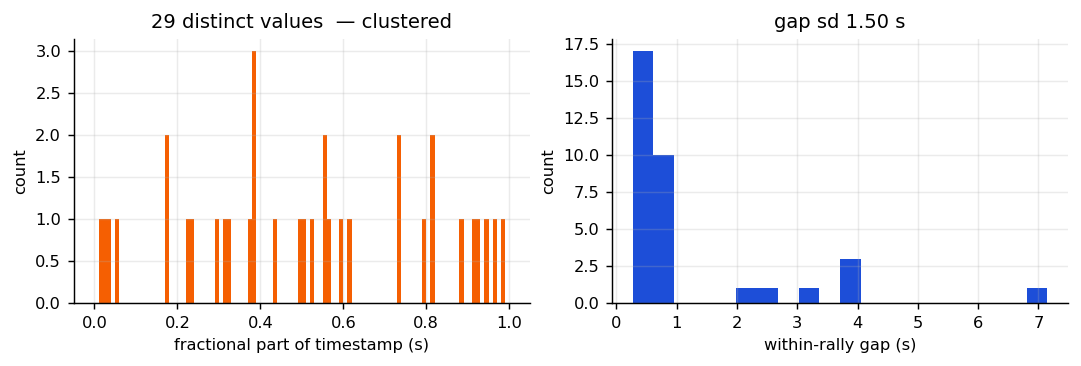

In [5]:
frac = np.round(gt.t.values % 1, 2)
uniq = len(set(frac))
counts = collections.Counter(frac)
top_share = counts.most_common(1)[0][1] / len(gt)

serve_frac = collections.Counter(np.round(gt.loc[gt.shot_class == "serve", "t"] % 1, 2))
d = np.diff(gt.t.values)
within = d[(gt["count"].values[1:] != 1)]

print("=" * 74)
print("ANNOTATION PRECISION")
print("=" * 74)
print(f"  distinct fractional parts   {uniq} of a possible 100")
print(f"  most common value           {counts.most_common(1)[0][0]:.2f}  "
      f"({top_share:.0%} of all shots)")
print(f"  serve fractional parts      {dict(serve_frac)}")
print(f"  within-rally gap            {within.mean():.2f} s, sd {within.std():.2f}")

PRECISE = uniq >= 40 and top_share < 0.15
TOL_S = 0.067 if PRECISE else 0.50

if PRECISE:
    print(f"""
  Fractional parts are well spread, consistent with frame-level marking.
  Timing will be scored at the paper's operating point, +/- 8 frames (67 ms).""")
else:
    print(f"""
  !! Fractional parts are clustered. These timestamps were almost certainly
     estimated or generated rather than marked frame by frame. Real contact
     times would spread roughly uniformly across all 100 hundredths.

     Consequence: detection CANNOT be scored at 67 ms against this file. A low
     F1 would measure the annotation, not the model.

     Timing is therefore reported at +/- {TOL_S:.2f} s and labelled as an
     annotation-limited estimate. The paper must not quote it as detection F1.

     Still valid regardless: shot COUNT, CLASS DISTRIBUTION, PLAYER BALANCE and
     RALLY STRUCTURE, none of which depend on precise timing.""")

fig, ax = plt.subplots(1, 2, figsize=(8.2, 2.7))
ax[0].hist(frac, bins=np.arange(0, 1.01, 0.01), color="#f55f02")
ax[0].set_xlabel("fractional part of timestamp (s)")
ax[0].set_ylabel("count")
ax[0].set_title(f"{uniq} distinct values"
                + ("" if PRECISE else "  — clustered"))
ax[1].hist(within, bins=20, color="#1d4ed8")
ax[1].set_xlabel("within-rally gap (s)"); ax[1].set_ylabel("count")
ax[1].set_title(f"gap sd {within.std():.2f} s")
plt.show()

## 3 · Run the pipeline

Uses the deployed models exactly as they ship. Nothing is retrained and no
threshold is adjusted for this clip.

In [6]:
from pathlib import Path
NB = Path("/content/drive/MyDrive/Colab Notebooks")
print([p.name for p in sorted(NB.glob("*.ipynb"))])

['00_ingest.ipynb', '01_player_registry.ipynb', '02_pose_extraction.ipynb', '03_canonicalize.ipynb', '04_baseline.ipynb', '05_skeleton_model.ipynb', '06a_continuous_pose.ipynb', '06b_contact_detector.ipynb', '07_eval_e2e.ipynb', '08_final_models.ipynb', '09_analyse.ipynb', '10_batch_test.ipynb', '11_visualise.ipynb', '12_pipeline_final.ipynb', '13_fps_experiment.ipynb', '14_demo_export.ipynb', '14_demo_export2.ipynb', '15_paper_metrics.ipynb', '16_paper_materials (1).ipynb', '16_paper_materials.ipynb', '16_reported_config.ipynb', '17_results.ipynb', '18_cascade_corrected.ipynb', '19_unseen_eval.ipynb', 'CancerClassification.ipynb', 'TT-0-Stage.ipynb', 'TT-Preflight-Stage.ipynb', 'rtmposer.ipynb']


In [7]:
import json, re, time
from pathlib import Path
import pandas as pd
from IPython import get_ipython

NB12 = Path("/content/drive/MyDrive/Colab Notebooks/12_pipeline_final.ipynb")

# Run notebook 12's setup cells only, stopping after analyse() is defined.
# Cell 14 onward calls analyse() on its own VIDEO_PATH and would process the
# wrong video.
ip = get_ipython()
for c in json.loads(NB12.read_text())["cells"]:
    if c["cell_type"] != "code":
        continue
    src = "".join(c["source"])
    ip.run_cell(src)
    if re.search(r"^\s*def analyse\(", src, re.M):
        print("\n--- analyse() defined, stopping here ---")
        break

assert "analyse" in dir(), "analyse() not defined"

# --- run on the test video --------------------------------------------------
VIDEO_PATH = str(vid_path)
VIDEO_ID   = VIDEO

t0 = time.time()
pred, rt = analyse(VIDEO_PATH, video_id=VIDEO_ID, force=True)
el = time.time() - t0

print(f"\n{len(pred)} shots in {el/60:.1f} min ({(NFR/FPS)/el:.2f}x realtime)")
print(pred.shot_class.value_counts().to_string())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU: Tesla T4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.7 MB/s eta 0:00:00
onnxruntime-gpu                       1.22.0
rtmlib                                0.0.16
ultralytics                           8.4.157
ultralytics-platform                  0.1.49
ultralytics-thop                      2.1.6

  NOW: Runtime > Restart session, then run from cell 3.
temperature 2.20   rally gap 1.5s
thresholds {'serve': 0.25, 'attack': 0.5, 'control': 1.01, 'defence': 1.01}
suppressed ['control', 'defence']
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 

Downloading: "https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/onnx_sdk/rtmpose-l_simcc-body7_pt-body7_420e-384x288-3f5a1437_20230504.zip" to /root/.cache/rtmlib/hub/checkpoints/rtmpose-l_simcc-body7_pt-body7_420e-384x288-3f5a1437_20230504.zip
100%|██████████| 98.9M/98.9M [00:03<00:00, 33.6MB/s]


load /root/.cache/rtmlib/hub/checkpoints/rtmpose-l_simcc-body7_pt-body7_420e-384x288-3f5a1437_20230504.onnx with onnxruntime backend
detector F1 0.881 | classifier macro-F1 0.792
stages defined
analyse() ready

--- analyse() defined, stopping here ---
  copying video to local disk ...
test_match2: 2,807 frames @ 60fps = 0.8 min
  !! 60fps — the pipeline is calibrated for 120fps. Windows, velocities and NMS will not mean what they should.


  gate:   0%|          | 0/2807 [00:00<?, ?it/s]

  [1] gate  21s -> 1 regions, 100% active


  pose:   0%|          | 0/2807 [00:00<?, ?it/s]

  [2] pose  110s -> 2,807 frames
  [3] canonicalised
  [4] contacts: 26
  [5] sides: 16 left / 10 right
  [6] classified (T=2.20)
  [7] kinematics + [8] 6 rallies

  26 shots, 6 rallies, 7 suppressed  [2 min = 3.1x realtime]

26 shots in 2.4 min (0.16x realtime)
shot_class
attack     15
serve       6
control     4
defence     1


## 4 · Shot count, classes, players

Robust to timing precision. These are the numbers to quote if section 2
flagged the annotation.

COUNTS
  annotated 35   detected 26   error -25.7%

  class       annotated  detected    error
  serve               8         6   -25.0%
  attack             10        15   +50.0%
  control            14         4   -71.4%
  defence             3         1   -66.7%

  player      annotated  detected
  left               18        16
  right              17        10


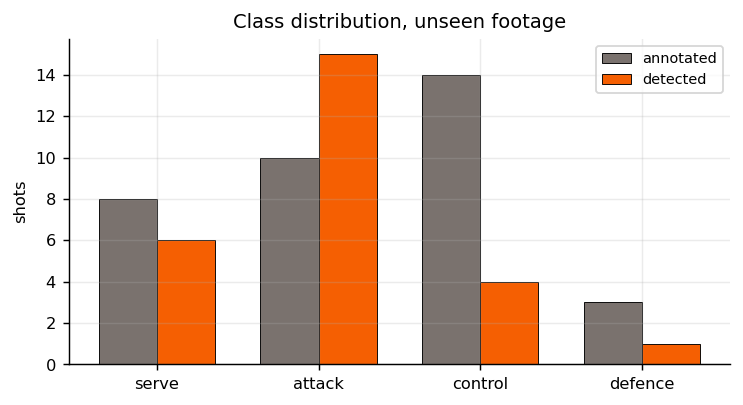

In [8]:
print("=" * 74)
print("COUNTS")
print("=" * 74)
err = (len(pred) - len(gt)) / len(gt)
print(f"  annotated {len(gt)}   detected {len(pred)}   error {err:+.1%}")

print(f"\n  {'class':<10}{'annotated':>11}{'detected':>10}{'error':>9}")
for c in CLASSES:
    a = int((gt.shot_class == c).sum())
    p = int((pred.shot_class == c).sum())
    e = (p - a)/a if a else float("nan")
    print(f"  {c:<10}{a:>11}{p:>10}{e:>+9.1%}")

print(f"\n  {'player':<10}{'annotated':>11}{'detected':>10}")
for s in ("left", "right"):
    print(f"  {s:<10}{int((gt.player==s).sum()):>11}{int((pred.player==s).sum()):>10}")

fig, ax = plt.subplots(figsize=(5.6, 3.0))
x = np.arange(len(CLASSES)); w = 0.36
ax.bar(x - w/2, [int((gt.shot_class==c).sum()) for c in CLASSES], w,
       label="annotated", color="#7a726e", edgecolor="black", linewidth=.5)
ax.bar(x + w/2, [int((pred.shot_class==c).sum()) for c in CLASSES], w,
       label="detected", color="#f55f02", edgecolor="black", linewidth=.5)
ax.set_xticks(x); ax.set_xticklabels(CLASSES); ax.set_ylabel("shots")
ax.set_title("Class distribution, unseen footage"); ax.legend(fontsize=8)
plt.show()

## 5 · Matching and per-shot accuracy

Greedy nearest-neighbour matching within the tolerance chosen in section 2.

DETECTION  at +/- 0.500 s   (annotation-limited, NOT comparable to the paper's 0.879)
  TP 10   FP 16   FN 25
  precision 0.385   recall 0.286   F1 0.328

  offset  mean -101 ms   sd 202 ms   median |err| 178 ms
  !! systematic bias of -101 ms. Check whether the
     annotation marks contact or some other moment (bounce, backswing).

CLASSIFICATION  on 10 matched shots
              precision    recall  f1-score   support

       serve      0.333     1.000     0.500         1
      attack      0.500     0.750     0.600         4
     control      0.000     0.000     0.000         4
     defence      0.000     0.000     0.000         1

    accuracy                          0.400        10
   macro avg      0.208     0.438     0.275        10
weighted avg      0.233     0.400     0.290        10

         serve  attack  control  defence  recall
serve        1       0        0        0    1.00
attack       1       3        0        0    0.75
control      1       3        0        0    0.

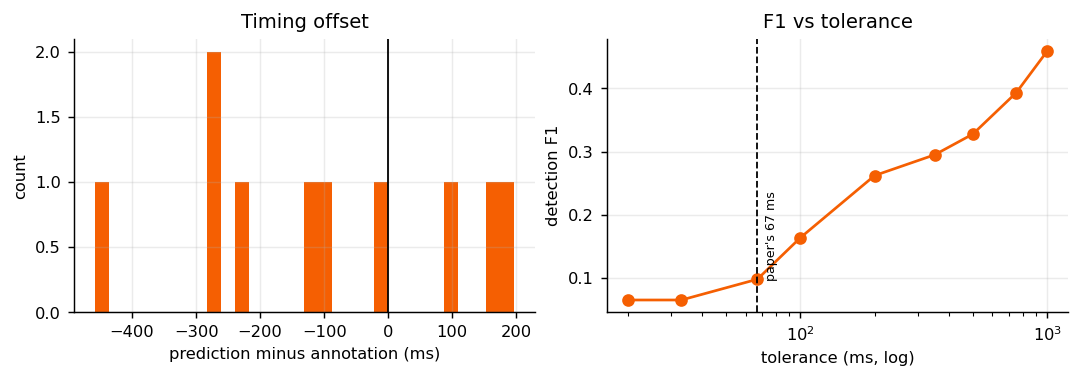


  Where this curve plateaus is the annotation's own precision.
  If it only saturates past ~200 ms, the timestamps are not frame-accurate.


In [9]:
def match(pred_t, true_t, tol):
    used, pairs = set(), []
    order = np.argsort(pred_t)
    for pi in order:
        best, bd = None, tol + 1e-9
        for ti, tt in enumerate(true_t):
            if ti in used:
                continue
            dd = abs(pred_t[pi] - tt)
            if dd < bd:
                best, bd = ti, dd
        if best is not None:
            used.add(best); pairs.append((pi, best))
    return pairs

pt, tt = pred.timestamp_s.values, gt.t.values
pairs = match(pt, tt, TOL_S)
TP = len(pairs); FP = len(pt) - TP; FN = len(tt) - TP
P_, R_ = TP/max(TP+FP, 1), TP/max(TP+FN, 1)
F1 = 2*P_*R_/max(P_+R_, 1e-9)

print("=" * 74)
print(f"DETECTION  at +/- {TOL_S:.3f} s"
      + ("" if PRECISE else "   (annotation-limited, NOT comparable to the paper's 0.879)"))
print("=" * 74)
print(f"  TP {TP}   FP {FP}   FN {FN}")
print(f"  precision {P_:.3f}   recall {R_:.3f}   F1 {F1:.3f}")

offs = np.array([pt[pi] - tt[ti] for pi, ti in pairs])
print(f"\n  offset  mean {offs.mean()*1000:+.0f} ms   "
      f"sd {offs.std()*1000:.0f} ms   median |err| {np.median(abs(offs))*1000:.0f} ms")
if abs(offs.mean()) > 0.05:
    print(f"  !! systematic bias of {offs.mean()*1000:+.0f} ms. Check whether the")
    print(f"     annotation marks contact or some other moment (bounce, backswing).")

# classification on matched pairs
yt = np.array([C2I[gt.shot_class.iloc[ti]] for _, ti in pairs])
yp = np.array([C2I[pred.shot_class.iloc[pi]] for pi, _ in pairs])
print("\n" + "=" * 74)
print(f"CLASSIFICATION  on {len(pairs)} matched shots")
print("=" * 74)
print(classification_report(yt, yp, target_names=CLASSES, digits=3,
                            zero_division=0, labels=range(4)))
cm = confusion_matrix(yt, yp, labels=range(4))
cmdf = pd.DataFrame(cm, index=CLASSES, columns=CLASSES)
cmdf["recall"] = (np.diag(cm)/np.maximum(cm.sum(1), 1)).round(3)
print(cmdf.to_string())

side_ok = np.mean([pred.player.iloc[pi] == gt.player.iloc[ti] for pi, ti in pairs])
print(f"\n  side attribution {side_ok:.3f}   (paper: 0.994)")

fig, ax = plt.subplots(1, 2, figsize=(8.2, 2.8))
ax[0].hist(offs*1000, bins=30, color="#f55f02")
ax[0].axvline(0, c="black", lw=1)
ax[0].set_xlabel("prediction minus annotation (ms)"); ax[0].set_ylabel("count")
ax[0].set_title("Timing offset")
tols = np.array([0.02, 0.033, 0.067, 0.1, 0.2, 0.35, 0.5, 0.75, 1.0])
f1s = []
for t_ in tols:
    pr = match(pt, tt, t_); tp = len(pr)
    p_, r_ = tp/max(len(pt),1), tp/max(len(tt),1)
    f1s.append(2*p_*r_/max(p_+r_, 1e-9))
ax[1].plot(tols*1000, f1s, "o-", color="#f55f02")
ax[1].axvline(67, ls="--", c="black", lw=1)
ax[1].text(72, 0.1, "paper's 67 ms", fontsize=7, rotation=90)
ax[1].set_xscale("log"); ax[1].set_xlabel("tolerance (ms, log)")
ax[1].set_ylabel("detection F1"); ax[1].set_title("F1 vs tolerance")
plt.show()

print("\n  Where this curve plateaus is the annotation's own precision.")
print("  If it only saturates past ~200 ms, the timestamps are not frame-accurate.")

## 6 · Rally structure

Independent of timing precision, because it depends on gaps rather than
absolute times.

RALLIES
  annotated 1   detected 6   error +500.0%
  mean length  annotated 35.0   detected 4.3

  boundary F1 (+/-1 s) 0.000   (paper: 0.769)


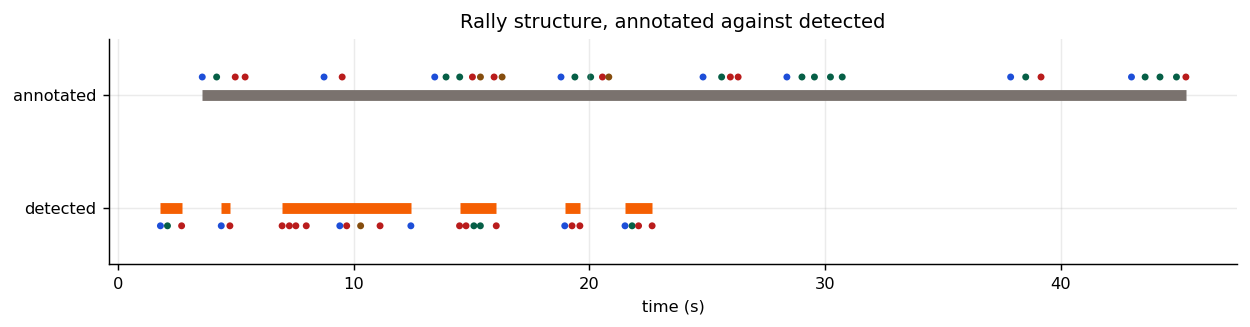

In [10]:
pred_r = pred.rally_id.nunique()
true_r = gt.rally.nunique()
print("=" * 74)
print("RALLIES")
print("=" * 74)
print(f"  annotated {true_r}   detected {pred_r}   error "
      f"{(pred_r-true_r)/true_r:+.1%}")
print(f"  mean length  annotated {len(gt)/true_r:.1f}   "
      f"detected {len(pred)/max(pred_r,1):.1f}")

# boundary F1 at 1 s
tb = gt.groupby("rally").t.min().values[1:]
pb = pred.groupby("rally_id").timestamp_s.min().values[1:]
bp = match(pb, tb, 1.0)
btp = len(bp)
bP, bR = btp/max(len(pb),1), btp/max(len(tb),1)
print(f"\n  boundary F1 (+/-1 s) {2*bP*bR/max(bP+bR,1e-9):.3f}   (paper: 0.769)")

fig, ax = plt.subplots(figsize=(9.5, 2.4))
for r in gt.rally.unique():
    g = gt[gt.rally == r]
    ax.plot([g.t.min(), g.t.max()], [1, 1], lw=6, solid_capstyle="butt",
            color="#7a726e")
for r in pred.rally_id.unique():
    g = pred[pred.rally_id == r]
    ax.plot([g.timestamp_s.min(), g.timestamp_s.max()], [0, 0], lw=6,
            solid_capstyle="butt", color="#f55f02")
ax.scatter(gt.t, np.ones(len(gt)) + 0.16, s=8,
           c=[PAL[c] for c in gt.shot_class])
ax.scatter(pred.timestamp_s, np.zeros(len(pred)) - 0.16, s=8,
           c=[PAL[c] for c in pred.shot_class])
ax.set_yticks([0, 1]); ax.set_yticklabels(["detected", "annotated"])
ax.set_xlabel("time (s)"); ax.set_ylim(-0.5, 1.5)
ax.set_title("Rally structure, annotated against detected")
plt.show()

## 7 · What to report

In [11]:
print("=" * 74)
print("UNSEEN FOOTAGE SUMMARY")
print("=" * 74)
print(f"  clip                 {NFR/FPS/60:.1f} min at {FPS:.0f} fps")
print(f"  shot count           {len(pred)} detected against {len(gt)} annotated "
      f"({err:+.1%})")
print(f"  rallies              {pred_r} against {true_r}")
print(f"  side attribution     {side_ok:.3f}")
print(f"  classification       macro-F1 "
      f"{f1_score(yt, yp, average='macro', zero_division=0):.3f} on matched shots")
print(f"  detection            F1 {F1:.3f} at +/- {TOL_S*1000:.0f} ms")

if not PRECISE:
    print(textwrap.dedent(f"""
  HOW TO WRITE THIS UP

    The annotation is not frame-accurate (section 2), so the detection figure
    above is NOT comparable to the paper's 0.879 and must not be presented as
    such. Report it as an annotation-limited check at +/- {TOL_S*1000:.0f} ms, or omit it.

    Quote instead the results that do not depend on precise timing:
    shot count, class distribution, player balance, rally structure.

    Suggested wording:

      "On {NFR/FPS/60:.1f} minutes of footage from outside the dataset, the pipeline
       detected {len(pred)} shots against {len(gt)} hand-annotated shots ({err:+.1%}) and
       recovered {pred_r} rallies against {true_r}. Contact times in this annotation
       were marked to approximately 0.1 s, so per-shot timing accuracy is
       not evaluated against it."

    To recover a citable detection number, re-annotate 60 to 90 shots with a
    frame stepper. At 120 fps that is 8 ms per frame, comfortably finer than
    the 67 ms operating point."""))
else:
    print(textwrap.dedent("""
  The annotation is frame-accurate, so every number above is directly
  comparable to the paper's held-out results. This is the external validation
  the limitations section calls for."""))

UNSEEN FOOTAGE SUMMARY
  clip                 0.4 min at 120 fps
  shot count           26 detected against 35 annotated (-25.7%)
  rallies              6 against 1
  side attribution     0.400
  classification       macro-F1 0.275 on matched shots
  detection            F1 0.328 at +/- 500 ms

HOW TO WRITE THIS UP

  The annotation is not frame-accurate (section 2), so the detection figure
  above is NOT comparable to the paper's 0.879 and must not be presented as
  such. Report it as an annotation-limited check at +/- 500 ms, or omit it.

  Quote instead the results that do not depend on precise timing:
  shot count, class distribution, player balance, rally structure.

  Suggested wording:

    "On 0.4 minutes of footage from outside the dataset, the pipeline
     detected 26 shots against 35 hand-annotated shots (-25.7%) and
     recovered 6 rallies against 1. Contact times in this annotation
     were marked to approximately 0.1 s, so per-shot timing accuracy is
     not evaluated

---
## Before running

1. Put `{VIDEO}.mp4` and `{VIDEO}_gt.txt` in `raw/external/`
2. Make sure `analyse()` is importable, or paste it into cell 3
3. Run in order

The precision check in section 2 decides the tolerance for everything after
it. If it flags the annotation, the timing number is not usable in the paper,
but the count, class and rally results still are.
